# jev vs. open alternatives on document tasks

**jev** (TypeSafe AI's "System One" decision model) answers typed questions — yes/no (*Noul*), pick-one (*Choice*), rubric (*Score*) — about a text `state`, returning calibrated probabilities instead of generated text. This notebook puts it head-to-head with open alternatives on four document-pipeline chores:

| Task | Ground truth | jev | Open decoder (Modal) | Open encoders (local) | Specialised open tool |
|---|---|---|---|---|---|
| Language detection | Wikipedia excerpts, 12 languages | Choice(12) | Qwen3.5-4B direct-logits | Laya, jeff | lingua |
| Orientation detection | pages scanned at 0/90/180/270° | Choice(4) over 4-way OCR | same | same | tesseract OSD |
| Document classification | RVL-CDIP scans, 16 classes | Choice(16) over OCR text | same | same | — |
| Bundle splitting | concatenated articles | Choice(2) per page boundary | same | same | — |
| Parse-tier triage | degraded scans, CER vs. source text | Choice(2) on liteparse signals + OCR excerpt | same | same | confidence/length heuristic |

Two things to keep in mind throughout:

* **jev is text-only** (`state` = string / JSON / array; [no images yet](https://docs.typesafe.ai/concepts/state)). Every PDF goes through [liteparse](https://github.com/run-llama/liteparse) (pdfium + tesseract) first.
* **Two kinds of open model.** A *decoder* (Qwen3.5-4B on Modal) and two *encoders*: [Laya](https://huggingface.co/convaiinnovations/laya), a 421M ModernBERT with a jev-compatible decision head (same state/questions schema, all questions in one pass; runs on the laptop; we use its `typed-decisions` checkpoint with the token budgets raised to 2048/512), and [jeff](https://github.com/logan-markewich/jeff), a self-hosted implementation of the jev System One API on gliformer-large (400M DeBERTa).
* **The open decoder is read out SemIf-style**: one forward pass, next-token logits restricted to the option letters, softmax. That is what the [SemIf / OpenJev](https://github.com/TheoLeeCJ/SemIf) baseline on [JevBench](https://benchmarkheaven.com/jev-models) does.

References: [jev quickstart](https://docs.typesafe.ai/introduction/quickstart) · [models & pricing](https://docs.typesafe.ai/models) · [confidence](https://docs.typesafe.ai/confidence) · [JevBench](https://benchmarkheaven.com/jev-models) · [liteparse docs](https://developers.llamaindex.ai/liteparse/)

## 0. Setup

```bash
uv sync
cp .env.example .env            # add TYPESAFE_API_KEY
uv run build-corpus all         # ~5-10 min: downloads Wikipedia/RVL-CDIP samples, renders + OCRs PDFs
uv run modal deploy modal_app.py   # once: serves Qwen3.5-4B on an L4
uv run jupyter lab notebooks/
```

In [18]:
import os, sys, json
from pathlib import Path
from dotenv import load_dotenv

os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
load_dotenv(".env")
assert os.environ.get("TYPESAFE_API_KEY"), "set TYPESAFE_API_KEY in .env"

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

from jev_vs import tasks, evalh
from jev_vs.corpus import load_manifest, LANG_NAMES, RVL_CDIP_LABELS
from jev_vs.decisions import JevBackend, OpenLogitsBackend, summarize, save_results, fanout_jev, sequential
from jev_vs.baselines import LinguaBackend, TesseractOSDBackend, HeuristicTriageBackend, LayaBackend

RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 80)

## 1. liteparse in 60 seconds

[liteparse](https://github.com/run-llama/liteparse) wraps pdfium (rendering, native text with positions) and tesseract (OCR) behind one object to power a few core primitives:

* `is_complex(pdf)`: cheap per-page signals (scanned? sparse? garbled?) and a `needs_ocr` verdict, without a full parse
* `parse(pdf)`: text per page. OCR runs **only** on pages and images that have no native text
* `screenshot(pdf)`: rasterise pages to PNG bytes

In [19]:
from liteparse import LiteParse

parser = LiteParse(ocr_enabled=True, ocr_language="eng", dpi=200, output_format="text", quiet=True)

# rendered from text: has a native text layer
sample_native = load_manifest("language")[0]["path"]     

# image-only PDF: needs OCR
sample_scan = load_manifest("classify")[0]["path"]     

for p in (sample_native, sample_scan):
    # ScreenshotResult: page_num, width, height, image_bytes (PNG)
    stats = parser.is_complex(p)[0] 
    print(p)
    print(
        f"  needs_ocr={stats.needs_ocr} reasons={stats.reasons} full_page_image={stats.full_page_image} "
        f"native_text_length={stats.text_length} text_coverage={stats.text_coverage:.2f}"
    )

data/language/en_00.pdf
  needs_ocr=False reasons=[] full_page_image=False native_text_length=1569 text_coverage=0.17
data/classify/invoice_00.pdf
  needs_ocr=True reasons=['scanned'] full_page_image=True native_text_length=0 text_coverage=-0.00


In [20]:
# Same parse() call for both; liteparse decides per page whether to OCR.
for p in (sample_native, sample_scan):
    result = parser.parse(p)
    page = result.pages[0]
    confs = [t.confidence for t in page.text_items if t.confidence is not None]   # None for native text, 0-1 for OCR
    print(
        f"--- {p}: {result.total_pages} page(s), producer={result.producer!r}, "
        f"{len(page.text_items)} text items, OCR confidence={sum(confs)/len(confs) if confs else None}"
    )
    print(page.text[:400], "\n")

--- data/language/en_00.pdf: 1 page(s), producer='ReportLab PDF Library - (opensource)', 20 text items, OCR confidence=None
Acer washingtonense

Acer washingtonense is an extinct maple species in the family Sapindaceae described from
one fossil leaf and four fossil samaras. The species is solely known from the Early Eocene
sediments exposed in northeast Washington state, United States. It is one of three species
belonging to the extinct section Torada.

Acer washingtonense was described from a lone leaf specimen and fo 



Detected 16 diacritics


--- data/classify/invoice_00.pdf: 1 page(s), producer=None, 16 text items, OCR confidence=0.6641874928027391
    = acass.cone.        PHILIP MORRIS
        VOUCHER                           Tom

                                      b=  1%
Chestnut                              iid
       91 Northeast Bowlevard
   FL                 32601               fod 



1 754 x 1000 px


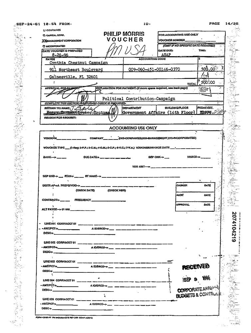

In [21]:
from PIL import Image
import io

# ScreenshotResult: page_num, width, height, image_bytes (PNG)
shot = parser.screenshot(sample_scan, page_numbers=[1])[0]      
print(shot.page_num, shot.width, "x", shot.height, "px")

display(Image.open(io.BytesIO(shot.image_bytes)).resize((shot.width // 3, shot.height // 3)))

## 2. The decision shape

A `Decision` is `(state, question, options)` grouping plus the ground truth.

Backends all return a `DecisionResult` with `choice`, `probabilities`, `confidence`, latency, tokens and attributed cost.

In [22]:
# One raw jev call first, so the wire format is visible before the helpers take over.
from typesafe_sdk import TypeSafeClient, Choice, Noul

with TypeSafeClient() as client:
    resp = client.system_one(
        state=parser.parse(sample_native).pages[0].text[:1200],
        questions={
            "language": Choice(
                instructions="Which language is this document written in?",
                criteria={"en": "English", "de": "German", "fr": "French", "other": "None of these"}
            ),
            "is_article": Noul(
                instructions="Is this an encyclopedia-style article?"
            ),
        },

    )
print(json.dumps(resp.model_dump(), indent=1))

{
 "model": "jev-1.13.0",
 "usage": {
  "input_tokens": 643,
  "output_tokens": 63
 },
 "answers": {
  "language": {
   "type": "choice",
   "choice": "en",
   "confidence": 1.0,
   "probabilities": {
    "other": 0.0,
    "de": 0.0,
    "fr": 0.0,
    "en": 1.0
   }
  },
  "is_article": {
   "type": "noul",
   "noul": 0.91
  }
 }
}


The response returns a few important things: `choice` (argmax), `probabilities` (sums to 1), `confidence` (spread of the distribution), and `usage.input_tokens` for cost.

In [23]:
# commercial, hosted, $0.042 / M input tokens
jev  = JevBackend(concurrency=16)                       

# modal deploy modal_app.py first
open_ = OpenLogitsBackend(gpu="L4", batch_size=8)       

# 421M encoder, runs locally (MPS/CPU), budgets raised to 2048/512 tokens
laya = LayaBackend(subfolder="typed-decisions")         

# jeff: a self-hosted jev-compatible server on gliformer-large (400M). Same wire format, same SDK, just a base_url.
#   local:  JEFF_API_KEYS=devkey uv run jeff        (in the jeff repo)      -> JEFF_BASE_URL=http://localhost:8000
#   modal:  JEFF_GPU=L4 JEFF_API_KEYS=k1 uv run modal deploy deploy/modal_gpu.py -> JEFF_BASE_URL=https://...modal.run
jeff = JevBackend(base_url=os.environ["JEFF_BASE_URL"], api_key=os.environ.get("JEFF_API_KEY", "devkey"), name="jeff", concurrency=8, timeout=300, usd_per_input_token=0.0)

print("jev:", jev.model or "jev-latest", "| decoder:", open_.name, "| laya on:", laya.device, "| jeff at:", jeff.base_url)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/loganmarkewich/jev_vs/.venv/lib/python3.12/site-packages/laya/agent.py:385: RuntimeWarning: laya: this checkpoint ships temperatures outside [0.5, 5] which would distort confidence; clamping choice:11+=0.1006. Treat confidence from the affected buckets as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder)


jev: jev-latest | decoder: open:Qwen3.5-4B | laya on: mps | jeff at: https://llamaindex-research--jeff-gpu-server-web.modal.run


In [24]:
def run_task(name, decisions, backends, extra=None):
    res = {}
    for b in backends:
        print(f"[{name}] running {b.name} on {len(decisions)} decisions ...")
        res[b.name] = b.run(decisions)
        save_results(res[b.name], RESULTS / f"{name}_{b.name.replace(':', '_').replace('/', '_')}.jsonl")
    
    df = evalh.compare(res)
    display(df.style.format({"accuracy": "{:.1%}", "p50_latency_s": "{:.2f}", "p95_latency_s": "{:.2f}", "usd_per_1k": "${:.4f}", "mean_confidence": "{:.2f}"}))
    evalh.plot_task(df, name); plt.show()
    return res, df

all_tables = {}

## 3. Under the hood: four ways to turn text into a probability

| | **jev** (TypeSafe) | **Qwen3.5-4B, direct logits** (SemIf-style) | **Laya** | **jeff** (gliformer-large) |
|---|---|---|---|---|
| Family | undisclosed | decoder (causal LM) | encoder (ModernBERT-large) | encoder (DeBERTa) |
| Parameters | undisclosed | 4B | 421M | 576M |
| How options are read | native typed output, all questions in one API call | next-token logits over the letters A, B, C… at the answer position; softmax over just those | one `[MASK]` slot per option appended to the prompt; a 2-layer transformer head scores each slot; softmax | each option is a label string ("key: description") in a named group; label-vs-text scores, sigmoid, then normalised |
| Training objective | RLCD: reinforcement learning rewarded on calibration ("answers given 90% should be right 90% of the time") | none for this task: pre-training + instruction tuning, we just read the logits | RLCD against strictly proper scoring rules (log / spherical score, ranked probability score for ordinal) | supervised multi-task heads (NER, classification, structuring, embeddings) |
| Calibration | optimised for; ships `confidence` | uncalibrated by construction (SemIf labels it "conditional option score") | optimised for; card reports ECE 0.47 → 0.08 after a temperature refit | post-hoc temperature scaling (T = 3.2) |
| Context / options | 32k tokens state, up to 255 options | 8k in our server; options limited by single-token letters (26) | 512–1024 tokens, budget shared with options; documented to fall off past ~20 options | 20k chars state, 64 labels per request |

**What we actually know about jev.** TypeSafe's [launch post](https://typesafe.ai/blog/introducing-system-one-models-and-jev) and [docs](https://docs.typesafe.ai/introduction/machine-learning-primer) hint at three things: it is *non-autoregressive* ("generates all outputs in a single query" via a "parallel sampler"), it does not generate text at all, and it was trained with **Reinforcement Learning for Calibrated Decisions (RLCD)**, where the reward is the calibration of the probabilities rather than human preference. Architecture type, size, and the exact reward are not disclosed.

## 4. Language detection

State: the first ~1200 characters of native PDF text. 

Options: the 12 languages, described in one line each. 

**lingua** is the specialised baseline: a statistical n-gram detector, free, sub-millisecond, and hard to beat on clean text. How close can models get?

In [25]:
lang_decisions = tasks.language_decisions()
print(len(lang_decisions), "decisions;", lang_decisions[0].question)
print(lang_decisions[0].state[:200])

48 decisions; Which language is this document written in?
Acer washingtonense

Acer washingtonense is an extinct maple species in the family Sapindaceae described from
one fossil leaf and four fossil samaras. The species is solely known from the Early Eocene


[language] running jev on 48 decisions ...
[language] running open:Qwen3.5-4B on 48 decisions ...
[language] running laya on 48 decisions ...
[language] running jeff on 48 decisions ...
[language] running lingua on 48 decisions ...


,n,accuracy,p50_latency_s,p95_latency_s,usd_per_1k,mean_confidence
backend,,,,,,
jev,48,100.0%,0.13,0.25,$0.0405,1.00
open:Qwen3.5-4B,48,100.0%,0.17,1.74,$0.0965,0.97
laya,48,39.6%,0.11,0.17,$0.0000,0.53
jeff,48,47.9%,0.39,1.42,$0.0000,0.07
lingua,48,100.0%,0.00,0.00,$0.0000,1.00


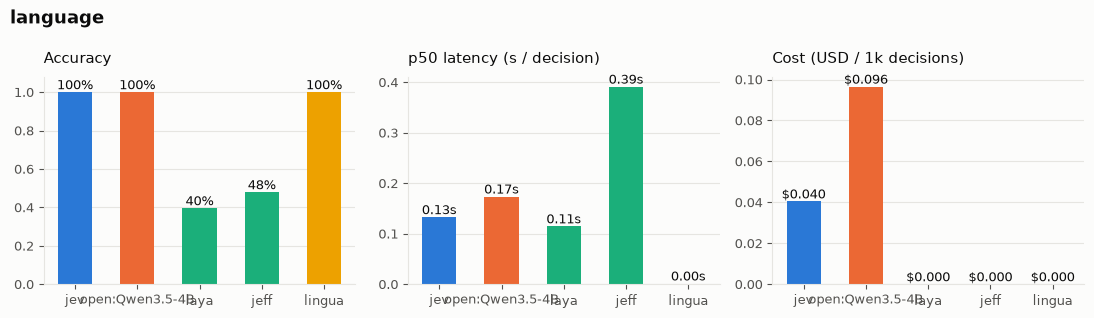

In [28]:
lang_results, lang_df = run_task("language", lang_decisions, [jev, open_, laya, jeff, LinguaBackend(list(LANG_NAMES))])
all_tables["language"] = lang_df

In [30]:
evalh.confusion(lang_results["jeff"])

predicted,de,el,en,es,fr,it,nl,pl,pt,vi
truth,,,,,,,,,,
de,2,0,2,0,0,0,0,0,0,0
el,0,4,0,0,0,0,0,0,0,0
en,1,0,2,0,0,0,0,1,0,0
es,0,1,1,2,0,0,0,0,0,0
fr,0,0,1,0,2,0,1,0,0,0
it,0,0,2,0,0,2,0,0,0,0
nl,1,0,0,1,0,0,2,0,0,0
pl,1,0,1,0,0,0,0,2,0,0
pt,0,0,1,1,0,0,0,1,1,0


## 5. Orientation detection

This task is unique for models that only handle text inputs. To detect orientation, we do a bit of preprocessing: render the document at four rotations (0°, 90°, 180°, 270°), OCR each one, and ask the model to choose which OCR output is readable.

The specialised baseline is tesseract's own orientation-and-script detection (`--psm 0`), which looks at glyph shapes and needs no language model at all.

In [31]:
# Rotate the scan four ways, OCR each, and judge results
scan = load_manifest("orientation")[0]
shot = parser.screenshot(scan["path"], page_numbers=[1])[0]
img = Image.open(io.BytesIO(shot.image_bytes)).convert("RGB")
print("scanned", scan["rotation_cw"], "degrees clockwise\n")

candidates = {}
for angle in (0, 90, 180, 270):
    # PIL rotates counter-clockwise
    rotated = img.rotate(angle, expand=True, fillcolor="white")

    # an image-only PDF = a "scan"      
    buf = io.BytesIO(); rotated.save(buf, format="PDF", resolution=150)  

    # no native text, so liteparse OCRs it
    page = parser.parse(buf.getvalue()).pages[0] 
                       
    candidates[f"rotation_{angle}"] = page.text
    confs = [t.confidence for t in page.text_items if t.confidence is not None]
    print(f"rotate {angle:3d} ccw: {len(page.text):5d} chars, tesseract conf {sum(confs)/len(confs):.2f}   {page.text[:70]!r}")

scanned 0 degrees clockwise

rotate   0 ccw:  1633 chars, tesseract conf 0.96   '    Hans Weiss (author)\n\n\nHans Weiss (born 1950 is an Austrian writer '
rotate  90 ccw:   877 chars, tesseract conf 0.68   '"BUISNY  Kyuamj  Aydosojiyd  noge  VIA  UBWSS|ES\nUB  Jo  aquq\npue  oju'
rotate 180 ccw:  1809 chars, tesseract conf 0.68   '                                                         eauinb se    '
rotate 270 ccw:  1884 chars, tesseract conf 0.96   ' doctors  confidential  for  immediate  pharmaceutical   His  services'


- Upside-down text comes back as mirrored gibberish
- 90° candidates contain real words with high tesseract confidence, but these are not correct

`tasks.orientation_decisions()` executes the loop above for every scan (cached to `data/orientation/candidates.json`), truncates each page to 500 characters (our models have token limits!), and wraps them in one `Choice` question for each model under test.

In [32]:
orient_decisions = tasks.orientation_decisions()

ex = orient_decisions[0]
print(ex.question, "\n")

for k, v in ex.options.items():
    print(f"  {k:4s} {v}")

print("\ntruth:", ex.truth)

A scanned page was OCR'd four times, after rotating the image by 0, 90, 180 and 270 degrees. Only the correct rotation yields readable text; the others produce fragments and garbage. Which candidate is the readable one? 

  0    Candidate `rotation_0` is coherent, correctly oriented natural-language text.
  90   Candidate `rotation_90` is coherent, correctly oriented natural-language text.
  180  Candidate `rotation_180` is coherent, correctly oriented natural-language text.
  270  Candidate `rotation_270` is coherent, correctly oriented natural-language text.

truth: 0


[orientation] running jev on 32 decisions ...
[orientation] running open:Qwen3.5-4B on 32 decisions ...
[orientation] running laya on 32 decisions ...
[orientation] running jeff on 32 decisions ...
[orientation] running tesseract-osd on 32 decisions ...


,n,accuracy,p50_latency_s,p95_latency_s,usd_per_1k,mean_confidence
backend,,,,,,
jev,32,93.8%,0.24,0.31,$0.0538,0.87
open:Qwen3.5-4B,32,90.6%,1.75,1.88,$0.3887,0.90
laya,32,28.1%,0.20,0.24,$0.0000,0.02
jeff,32,21.9%,0.42,0.63,$0.0000,0.24
tesseract-osd,32,100.0%,0.55,0.57,$0.0000,0.97


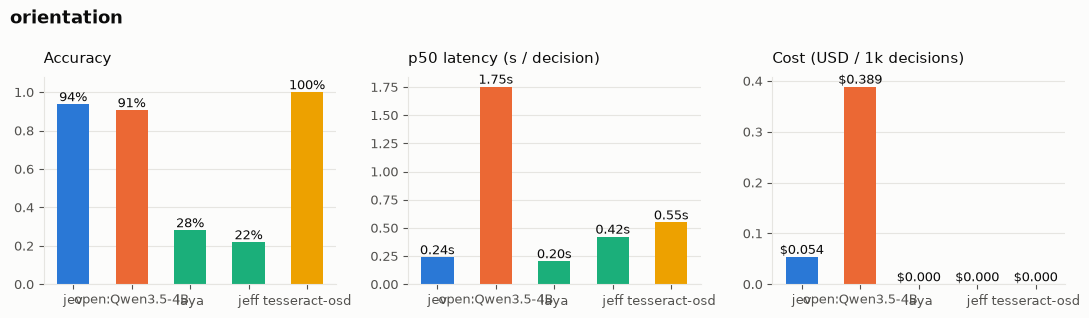

In [33]:
scan_images = {
    r["id"]: Image.open(io.BytesIO(parser.screenshot(r["path"], page_numbers=[1])[0].image_bytes)).convert("RGB")
    for r in load_manifest("orientation")
}

orient_results, orient_df = run_task("orientation", orient_decisions, [jev, open_, laya, jeff, TesseractOSDBackend(scan_images)])

all_tables["orientation"] = orient_df

In [34]:
# Where did each backend fail, and how confident was it?
pd.concat([evalh.errors(r).assign(backend=k) for k, r in orient_results.items()])

,id,truth,choice,confidence,backend
14,orient-014,0,270,0.680000,jev
29,orient-029,180,90,0.550000,jev
1,orient-001,270,180,0.853057,open:Qwen3.5-4B
29,orient-029,180,90,0.640333,open:Qwen3.5-4B
30,orient-030,90,0,0.955845,open:Qwen3.5-4B
0,orient-000,0,270,0.003000,laya
1,orient-001,270,90,0.015000,laya
2,orient-002,0,90,0.015900,laya
3,orient-003,270,90,0.004700,laya
4,orient-004,180,90,0.019000,laya


## 6. Document classification (RVL-CDIP, 16 classes)

Real scans from the tobacco-industry corpus, OCR'd by liteparse. 

Input State: up to 2,500 characters of OCR text. 
Options: the 16 RVL-CDIP classes with one-line descriptions ([structured descriptions](https://docs.typesafe.ai/primitives/advanced) with `what` / `not_for` / `examples` are the documented way to sharpen this further).

Note: no specialized baseline here, since that requires fine-tuning a specific classifier.

In [35]:
cls_decisions = tasks.classify_decisions()

ex = cls_decisions[0]
print(ex.question, "\n")

for k, v in ex.options.items():
    print(f"  {k:4s} {v}")

print("\ntruth:", ex.truth)

The state is OCR text from one scanned page. What kind of document is it? 

  advertisement Marketing or promotional material for a product, brand or event.
  budget Financial planning tables: budgets, cost breakdowns, allocations by line item.
  email An email message with To/From/Subject/Date headers.
  file_folder A file folder label or tab; almost no content beyond a title or code.
  form A blank or filled-in form with labelled fields and boxes.
  handwritten Predominantly handwritten notes or a handwritten letter.
  invoice An invoice, bill or purchase order listing items, quantities and amounts due.
  letter A typed business or personal letter with salutation and signature.
  memo An internal memorandum with MEMO/TO/FROM/RE style header.
  news_article A newspaper or magazine article with headline and columns of prose.
  presentation Slides or overhead transparencies: large text, bullets, one idea per page.
  questionnaire A survey or questionnaire with numbered questions and ans

[classify] running jev on 96 decisions ...
[classify] running open:Qwen3.5-4B on 96 decisions ...
[classify] running laya on 96 decisions ...
[classify] running jeff on 96 decisions ...


,n,accuracy,p50_latency_s,p95_latency_s,usd_per_1k,mean_confidence
backend,,,,,,
jev,96,54.2%,0.14,0.26,$0.0417,0.78
open:Qwen3.5-4B,96,51.0%,0.26,2.00,$0.1159,0.69
laya,96,24.0%,0.14,0.21,$0.0000,0.47
jeff,96,26.0%,0.32,0.64,$0.0000,0.10


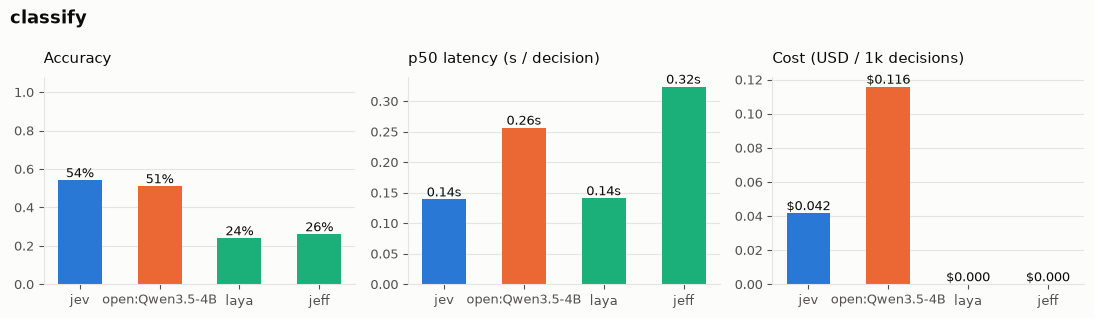

In [36]:
cls_results, cls_df = run_task("classify", cls_decisions, [jev, open_, laya, jeff])

all_tables["classify"] = cls_df

In [37]:
evalh.confusion(cls_results["jev"])

predicted,advertisement,budget,email,file_folder,form,invoice,letter,memo,news_article,presentation,questionnaire,resume,scientific_publication,scientific_report,specification
truth,,,,,,,,,,,,,,,
advertisement,1,0,0,4,0,0,0,1,0,0,0,0,0,0,0
budget,0,1,0,1,0,3,0,1,0,0,0,0,0,0,0
email,0,0,5,0,0,0,0,0,0,0,0,0,0,1,0
file_folder,0,1,0,5,0,0,0,0,0,0,0,0,0,0,0
form,0,0,0,0,1,1,1,2,0,0,0,0,0,0,1
handwritten,0,0,0,4,1,0,1,0,0,0,0,0,0,0,0
invoice,0,0,0,0,2,3,0,1,0,0,0,0,0,0,0
letter,1,0,0,0,0,0,4,1,0,0,0,0,0,0,0
memo,0,0,0,0,0,0,0,5,0,0,0,0,0,1,0


In [38]:
# Does accuracy rise when we only act on confident answers?
def accuracy_at_confidence(results, thresholds=(0.0, 0.3, 0.5, 0.7, 0.9)):
    df = evalh.frame(results)
    return pd.DataFrame({"threshold": t, "coverage": (df.confidence >= t).mean(), "accuracy": df[df.confidence >= t].correct.mean()} for t in thresholds)

pd.concat({k: accuracy_at_confidence(v) for k, v in cls_results.items()})

threshold  coverage  accuracy
jev             0        0.0  1.000000  0.541667
                1        0.3  0.968750  0.559140
                2        0.5  0.833333  0.625000
                3        0.7  0.697917  0.686567
                4        0.9  0.458333  0.818182
open:Qwen3.5-4B 0        0.0  1.000000  0.510417
                1        0.3  0.812500  0.589744
                2        0.5  0.739583  0.633803
                3        0.7  0.625000  0.716667
                4        0.9  0.375000  0.861111
laya            0        0.0  1.000000  0.239583
                1        0.3  0.729167  0.300000
                2        0.5  0.322917  0.419355
                3        0.7  0.187500  0.611111
                4        0.9  0.041667  0.750000
jeff            0        0.0  1.000000  0.260417
                1        0.3  0.000000       NaN
                2        0.5  0.000000       NaN
                3        0.7  0.000000       NaN
                4        0.9  0.000000       NaN

## 7. Splitting a bundle into documents

Scanners can produce one PDF with several documents inside. 

For every page after the first, we ask: *given the end of the previous page and the start of this one, does a new document begin here?* 

[split] running jev on 82 decisions ...
[split] running open:Qwen3.5-4B on 82 decisions ...
[split] running laya on 82 decisions ...
[split] running jeff on 82 decisions ...


,n,accuracy,p50_latency_s,p95_latency_s,usd_per_1k,mean_confidence
backend,,,,,,
jev,82,96.3%,0.13,0.27,$0.0304,0.94
open:Qwen3.5-4B,82,87.8%,0.14,1.78,$0.0699,0.75
laya,82,70.7%,0.09,0.12,$0.0000,0.02
jeff,82,73.2%,0.32,1.15,$0.0000,0.30


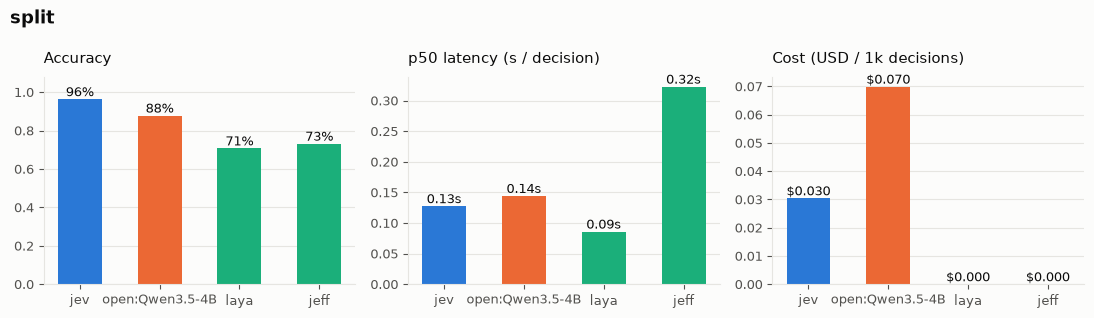

In [39]:
split_decisions = tasks.split_decisions()
split_results, split_df = run_task("split", split_decisions, [jev, open_, laya, jeff])
all_tables["split"] = split_df

In [40]:
def boundary_prf(results):
    df = evalh.frame(results)
    
    tp = ((df.choice == "new_document") & (df.truth == "new_document")).sum()
    fp = ((df.choice == "new_document") & (df.truth != "new_document")).sum()
    fn = ((df.choice != "new_document") & (df.truth == "new_document")).sum()
    
    p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
    
    return {"precision": p, "recall": r, "f1": 2 * p * r / max(p + r, 1e-9), "boundaries": int(tp + fn)}

pd.DataFrame({k: boundary_prf(v) for k, v in split_results.items()}).T

,precision,recall,f1,boundaries
jev,0.900000,1.000000,0.947368,27.0
open:Qwen3.5-4B,0.947368,0.666667,0.782609,27.0
laya,0.548387,0.629630,0.586207,27.0
jeff,0.631579,0.444444,0.521739,27.0


## 8. Parse-tier triage: is the cheap local parse good enough?

A common question in a document pipeline: parse locally for free, or pay for a heavier parser (vision model, agentic parse)? 

LiteParse already gives cheap signals (`is_complex`: scanned? sparse? garbled? layout elements?) and tesseract reports a mean confidence. We hand jev those signals **plus** an OCR excerpt and ask *local_ok* or *upgrade*.

Ground truth was generated by us. Each scan was rendered from a page whose text we know, then degraded (blur, 72-dpi downscale, noise, skew) and rotated. A page is `upgrade` if the local OCR's **character error rate** against the source text exceeds 10%.

The baseline is the rule was a basic heuristic: escalate when OCR confidence < 0.85 or the page has < 300 characters.

In [41]:
triage_decisions = tasks.triage_decisions()
print(json.dumps(triage_decisions[0].state, ensure_ascii=False, indent=1)[:900])
print("truth:", triage_decisions[0].truth, "| CER:", triage_decisions[0].meta["cer"])

{
 "complexity": {
  "needs_ocr": true,
  "reasons": [
   "scanned"
  ],
  "text_coverage": -0.0,
  "full_page_image": true,
  "is_garbled": false,
  "native_text_length": 0
 },
 "ocr": {
  "mean_confidence": 0.894,
  "chars": 1500,
  "excerpt": "Nồng     độ\n        độ là khái niệm cho     biết lượng     hóa chất trong  một hỗn   hợp, thưởng là đưng địch.\n    Dung địch bao gồm chất tan và đụng      mới.     Chất tạn càng nhiều trong một  lượng   đụng mới  cố\n    đình, thì  nồng độ cảng cao. Nông độ đạt giá  trị cao nhất,     ở những điều kiện môi trưởng    nhất\n    định  khi đụng địch bão hòa, có      nghĩa chất tạn  không thế hòa tạn thêm    vào đụng địch.\nNếu chất tạn được thêm vào một đụng địch đã bão hoà, nó sẽ không tạn nữa mà sẽ xây ra\n    hiện  tượng phân từ bị kết  nh   (biếng Anh: phase      separation), dẫn  đến  các pha đồng tồn tại\n    hoặc tạo huyền   phù  (còn  gợi  
truth: local_ok | CER: 0.0752


[triage] running jev on 48 decisions ...
[triage] running open:Qwen3.5-4B on 48 decisions ...
[triage] running laya on 48 decisions ...
[triage] running jeff on 48 decisions ...
[triage] running heuristic on 48 decisions ...


,n,accuracy,p50_latency_s,p95_latency_s,usd_per_1k,mean_confidence
backend,,,,,,
jev,48,85.4%,0.16,0.37,$0.0343,0.59
open:Qwen3.5-4B,48,95.8%,0.16,0.20,$0.0362,0.69
laya,48,52.1%,0.12,0.17,$0.0000,0.00
jeff,48,64.6%,0.35,0.64,$0.0000,0.47
heuristic,48,93.8%,0.00,0.00,$0.0000,1.00


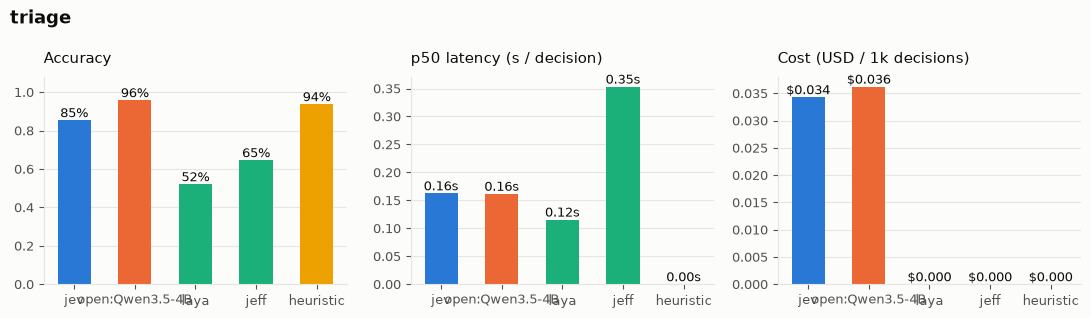

In [42]:
triage_results, triage_df = run_task("triage", triage_decisions, [jev, open_, laya, jeff, HeuristicTriageBackend()])
all_tables["triage"] = triage_df

## 9. Overview

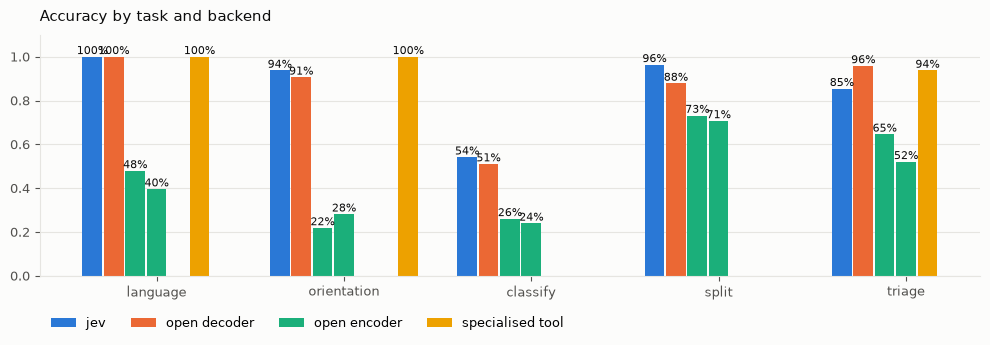

n  accuracy  p50_latency_s  p95_latency_s  \
task        backend                                                       
language    jev              48  1.000000   1.329026e-01   2.529088e-01   
            open:Qwen3.5-4B  48  1.000000   1.736701e-01   1.740866e+00   
            laya             48  0.395833   1.147455e-01   1.663601e-01   
            jeff             48  0.479167   3.912895e-01   1.423312e+00   
            lingua           48  1.000000   1.468396e-03   2.116917e-03   
orientation jev              32  0.937500   2.397678e-01   3.109730e-01   
            open:Qwen3.5-4B  32  0.906250   1.753322e+00   1.879806e+00   
            laya             32  0.281250   2.046298e-01   2.371181e-01   
            jeff             32  0.218750   4.221699e-01   6.272473e-01   
            tesseract-osd    32  1.000000   5.486034e-01   5.747247e-01   
classify    jev              96  0.541667   1.390895e-01   2.648856e-01   
            open:Qwen3.5-4B  96  0.510417   2.565729e-01   1.995426e+00   
            laya             96  0.239583   1.410040e-01   2.081506e-01   
            jeff             96  0.260417   3.237716e-01   6.439054e-01   
split       jev              82  0.963415   1.275841e-01   2.676195e-01   
            open:Qwen3.5-4B  82  0.878049   1.442679e-01   1.784574e+00   
            laya             82  0.707317   8.599825e-02   1.249370e-01   
            jeff             82  0.731707   3.227918e-01   1.153482e+00   
triage      jev              48  0.854167   1.625788e-01   3.697739e-01   
            open:Qwen3.5-4B  48  0.958333   1.617255e-01   1.969319e-01   
            laya             48  0.520833   1.156205e-01   1.740689e-01   
            jeff             48  0.645833   3.532300e-01   6.449308e-01   
            heuristic        48  0.937500   2.919696e-07   9.171199e-07   

                             usd_per_1k  mean_confidence  
task        backend                                       
language    jev                0.040457         0.999583  
            open:Qwen3.5-4B    0.096484         0.967754  
            laya               0.000000         0.532869  
            jeff               0.000000         0.073235  
            lingua             0.000000         1.000000  
orientation jev                0.053826         0.869687  
            open:Qwen3.5-4B    0.388709         0.900043  
            laya               0.000000         0.016694  
            jeff               0.000000         0.244019  
            tesseract-osd      0.000000         0.969938  
classify    jev                0.041731         0.775625  
            open:Qwen3.5-4B    0.115881         0.689677  
            laya               0.000000         0.470103  
            jeff               0.000000         0.101652  
split       jev                0.030411         0.944634  
            open:Qwen3.5-4B    0.069911         0.752635  
            laya               0.000000         0.018737  
            jeff               0.000000         0.304898  
triage      jev                0.034299         0.589792  
            open:Qwen3.5-4B    0.036222         0.691925  
            laya               0.000000         0.004956  
            jeff               0.000000         0.471244  
            heuristic          0.000000         1.000000

In [43]:
evalh.plot_overview(all_tables); plt.show()
pd.concat(all_tables, names=["task", "backend"])